## Problem 6 - Replication

Comparison of coefficients:
             Method  Intercept (alpha)  Slope (beta)
0  By hand (page 9)          22.636240      0.637361
1       statsmodels          22.636241      0.637361

Difference from 'by hand' values:
  alpha: 5.50e-07
  beta: 3.03e-09
Coefficients match within tolerance.


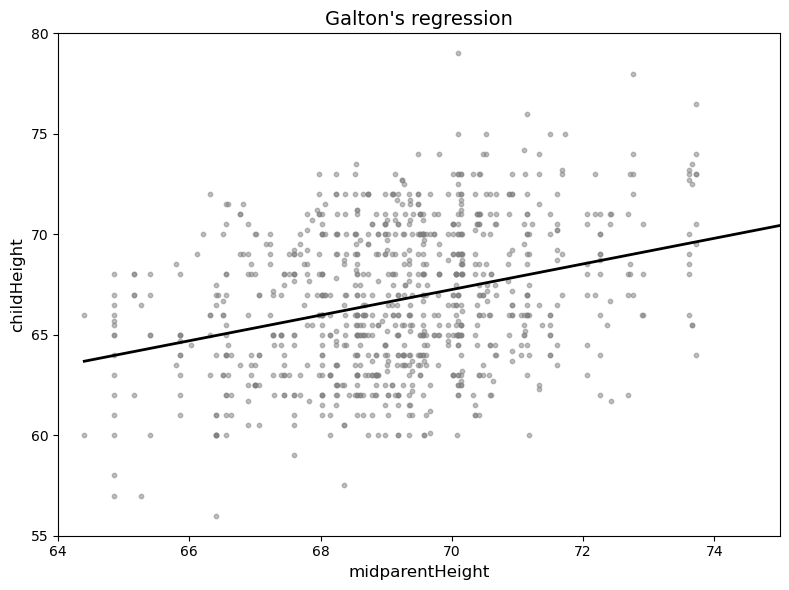

In [1]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

galton_data = sm.datasets.get_rdataset("GaltonFamilies", "HistData")
df = galton_data.data

x = df["midparentHeight"].astype(float)
y = df["childHeight"].astype(float)

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

alpha_sm = model.params["const"]
beta_sm = model.params["midparentHeight"]

comparison = pd.DataFrame({
    "Method": ["By hand (page 9)", "statsmodels"],
    "Intercept (alpha)": [22.63624, alpha_sm],
    "Slope (beta)": [0.6373609, beta_sm]
})

print("Comparison of coefficients:")
print(comparison)
print(f"\nDifference from 'by hand' values:")
print(f"  alpha: {abs(alpha_sm - 22.63624):.2e}")
print(f"  beta: {abs(beta_sm - 0.6373609):.2e}")

if abs(alpha_sm - 22.63624) > 1e-5 or abs(beta_sm - 0.6373609) > 1e-5:
    print("Warning: coefficients do not match!")
else:
    print("Coefficients match within tolerance.")

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.5, color='gray')
xgrid = np.linspace(x.min(), x.max(), 200)
plt.plot(xgrid, alpha_sm + beta_sm * xgrid, linewidth=2, color='black')

plt.xlabel("midparentHeight", fontsize=12)
plt.ylabel("childHeight", fontsize=12)
plt.title("Galton's regression", fontsize=14)

plt.xlim(64, 75)
plt.ylim(55, 80)

plt.tight_layout()
plt.show()